In [1]:
import importlib
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import db_config

from db_config import get_database_url, get_database_render_url
from sqlalchemy import create_engine

In [2]:
pd.set_option('display.float_format', '{:.3f}'.format)

In [3]:
engine_local = create_engine(get_database_url(), pool_pre_ping=True)
df = pd.read_sql(
    "SELECT * FROM public.pollen_by_date_time",
    engine_local
)

df.head()

,fdate,ftime,camps_point_id,analysis_time,alder_pollen,birch_pollen,grass_pollen,mugwort_pollen,olive_pollen,ragweed_pollen,pollen_total
0,2026-07-22,01:00:00,1,2026-07-22,0.000,0.000,15.098,2.173,0.000,0.000,17.270
1,2026-07-22,14:00:00,12,2026-07-22,0.000,0.000,10.583,3.919,0.000,0.000,14.503
2,2026-07-22,14:00:00,11,2026-07-22,0.000,0.000,13.553,2.347,0.000,0.000,15.900
3,2026-07-22,14:00:00,10,2026-07-22,0.000,0.000,8.599,4.739,0.000,0.000,13.338
4,2026-07-22,14:00:00,9,2026-07-22,0.000,0.000,7.813,5.191,0.000,0.000,13.004


In [4]:
df['fdate'] = pd.to_datetime(df['fdate'], format='%Y-%m-%d')
df['ftime'] = pd.to_datetime(df['ftime'], format='%H:%M:%S').dt.time
df['analysis_time'] = pd.to_datetime(df['analysis_time'], format='%Y-%m-%d')
df.head(24)

,fdate,ftime,camps_point_id,analysis_time,alder_pollen,birch_pollen,grass_pollen,mugwort_pollen,olive_pollen,ragweed_pollen,pollen_total
0,2026-07-22,01:00:00,1,2026-07-22,0.000,0.000,15.098,2.173,0.000,0.000,17.270
1,2026-07-22,14:00:00,12,2026-07-22,0.000,0.000,10.583,3.919,0.000,0.000,14.503
2,2026-07-22,14:00:00,11,2026-07-22,0.000,0.000,13.553,2.347,0.000,0.000,15.900
3,2026-07-22,14:00:00,10,2026-07-22,0.000,0.000,8.599,4.739,0.000,0.000,13.338
4,2026-07-22,14:00:00,9,2026-07-22,0.000,0.000,7.813,5.191,0.000,0.000,13.004
5,2026-07-22,14:00:00,8,2026-07-22,0.000,0.000,8.092,5.634,0.000,0.000,13.726
6,2026-07-22,14:00:00,7,2026-07-22,0.000,0.000,9.847,5.003,0.000,0.000,14.850
7,2026-07-22,14:00:00,6,2026-07-22,0.000,0.000,10.864,3.779,0.000,0.000,14.644
8,2026-07-22,14:00:00,5,2026-07-22,0.000,0.000,11.835,3.456,0.000,0.000,15.291
9,2026-07-22,14:00:00,4,2026-07-22,0.000,0.000,10.530,4.340,0.000,0.000,14.869


In [5]:
df.dtypes

fdate             datetime64[s]
ftime                    object
camps_point_id            int64
analysis_time     datetime64[s]
alder_pollen            float64
birch_pollen            float64
grass_pollen            float64
mugwort_pollen          float64
olive_pollen            float64
ragweed_pollen          float64
pollen_total            float64
dtype: object

In [6]:
df_grouped = df.groupby(['fdate', 'camps_point_id'])[
    ['alder_pollen', 'birch_pollen', 'grass_pollen', 'mugwort_pollen', 'olive_pollen', 'ragweed_pollen', 'pollen_total']
].mean()
df_grouped.tail(20)

alder_pollen  birch_pollen  grass_pollen  \
fdate      camps_point_id                                             
2026-07-21 11                     0.000         0.000        10.161   
           12                     0.000         0.000         9.318   
           13                     0.000         0.000         8.660   
           14                     0.000         0.000         8.398   
           15                     0.000         0.000         8.637   
2026-07-22 1                      0.000         0.000        12.615   
           2                      0.000         0.000        12.738   
           3                      0.000         0.000        12.644   
           4                      0.000         0.000        12.806   
           5                      0.000         0.000        14.048   
           6                      0.000         0.000        14.850   
           7                      0.000         0.000        13.519   
           8                      0.000         0.000        10.819   
           9                      0.000         0.000        10.651   
           10                     0.000         0.000        11.927   
           11                     0.000         0.000        16.042   
           12                     0.000         0.000        13.859   
           13                     0.000         0.000        13.591   
           14                     0.000         0.000        12.659   
           15                     0.000         0.000        12.901   

                           mugwort_pollen  olive_pollen  ragweed_pollen  \
fdate      camps_point_id                                                 
2026-07-21 11                       1.416         0.000           0.000   
           12                       2.068         0.000           0.000   
           13                       2.590         0.000           0.000   
           14                       2.634         0.000           0.000   
           15                       2.089         0.000           0.000   
2026-07-22 1                        4.016         0.000           0.000   
           2                        3.990         0.000           0.000   
           3                        4.329         0.000           0.000   
           4                        4.637         0.000           0.000   
           5                        4.031         0.000           0.000   
           6                        3.810         0.000           0.000   
           7                        5.091         0.000           0.000   
           8                        7.219         0.000           0.000   
           9                        6.466         0.000           0.000   
           10                       4.980         0.000           0.000   
           11                       2.624         0.000           0.000   
           12                       3.615         0.000           0.000   
           13                       4.622         0.000           0.000   
           14                       4.516         0.000           0.000   
           15                       3.904         0.000           0.000   

                           pollen_total  
fdate      camps_point_id                
2026-07-21 11                    11.577  
           12                    11.387  
           13                    11.250  
           14                    11.032  
           15                    10.726  
2026-07-22 1                     16.631  
           2                     16.728  
           3                     16.974  
           4                     17.443  
           5                     18.079  
           6                     18.660  
           7                     18.610  
           8                     18.038  
           9                     17.117  
           10                    16.908  
           11                    18.667  
           12                    17.473  
           13  

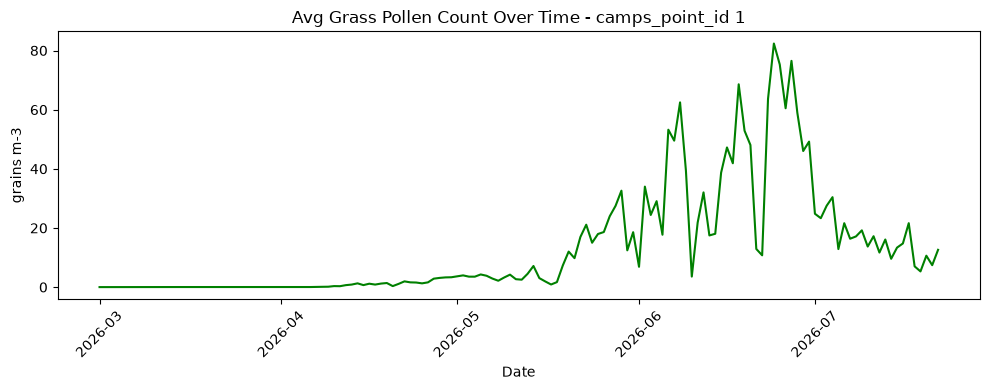

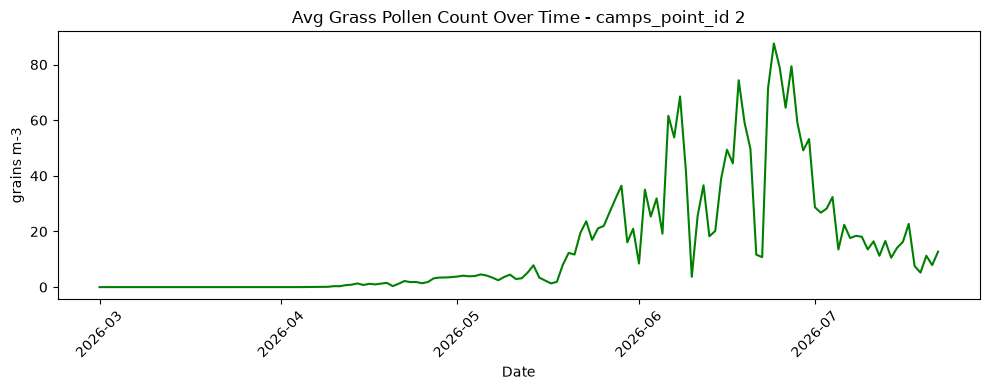

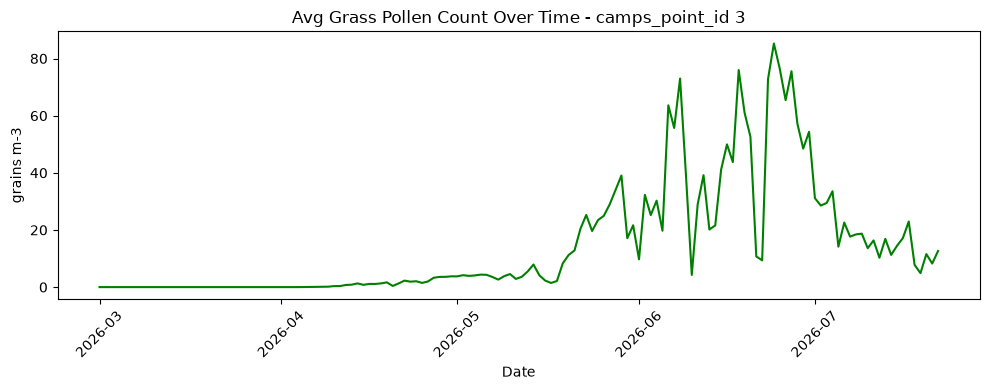

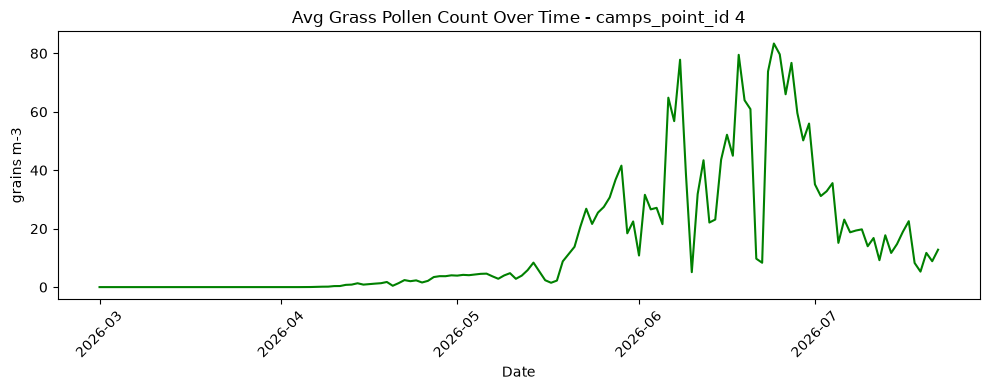

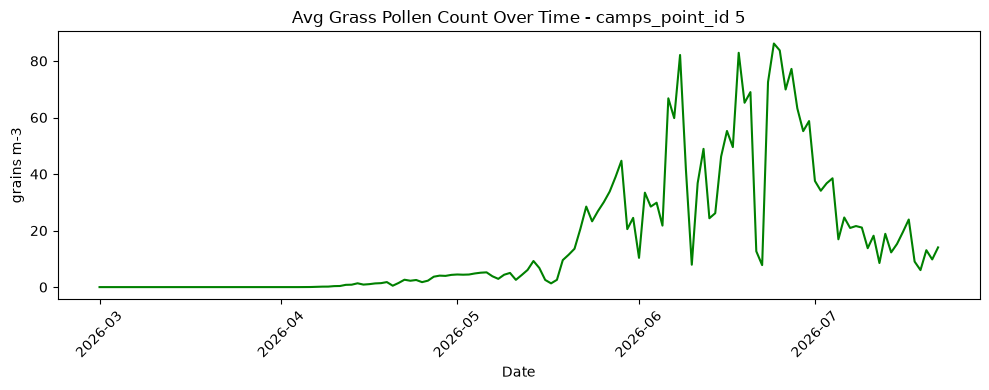

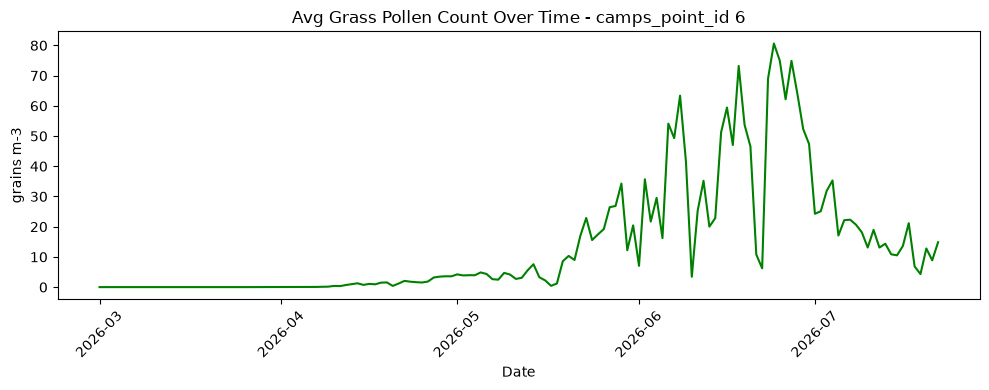

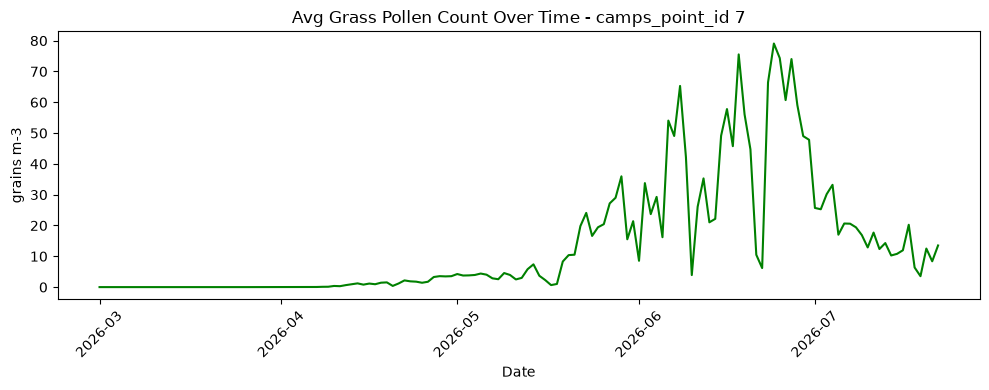

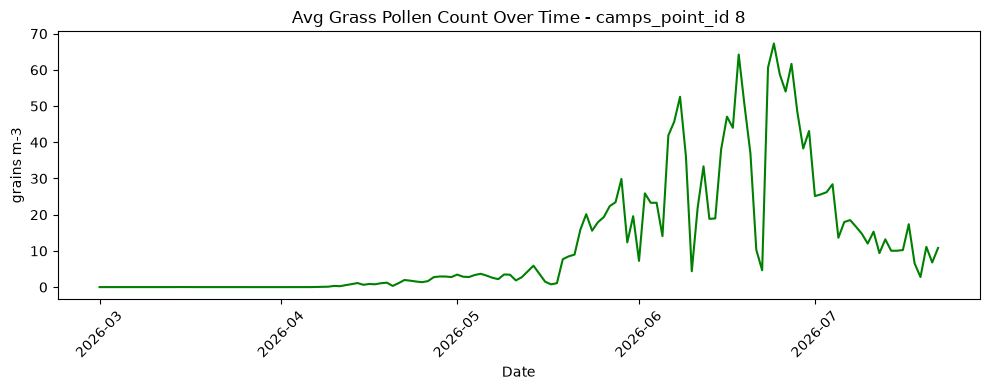

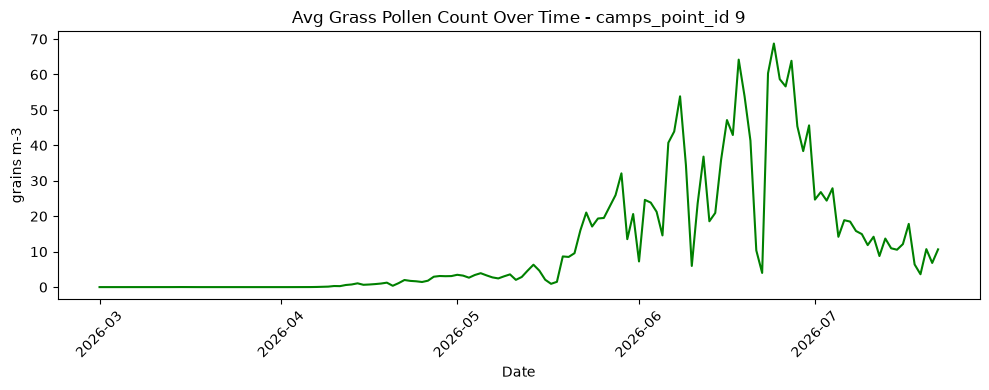

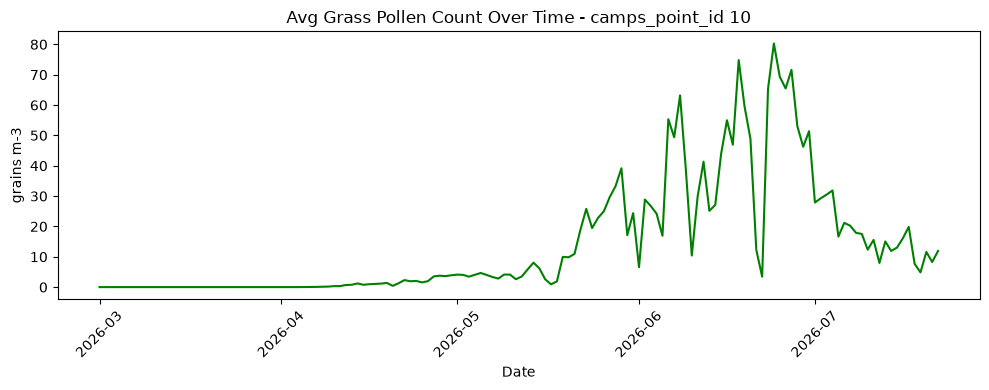

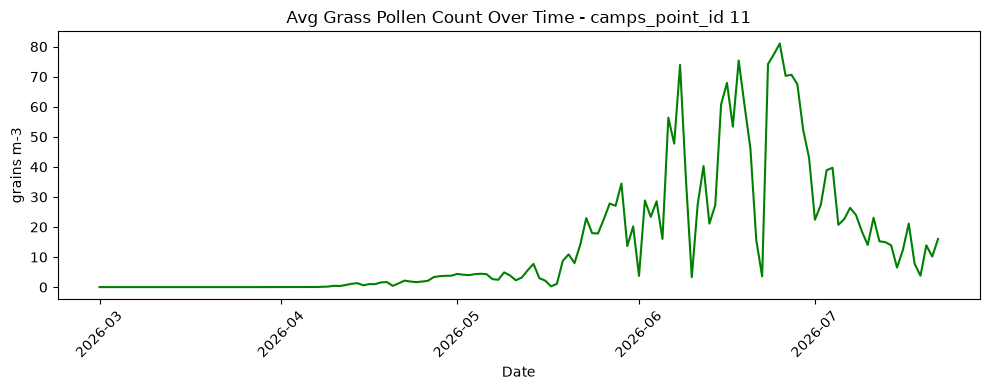

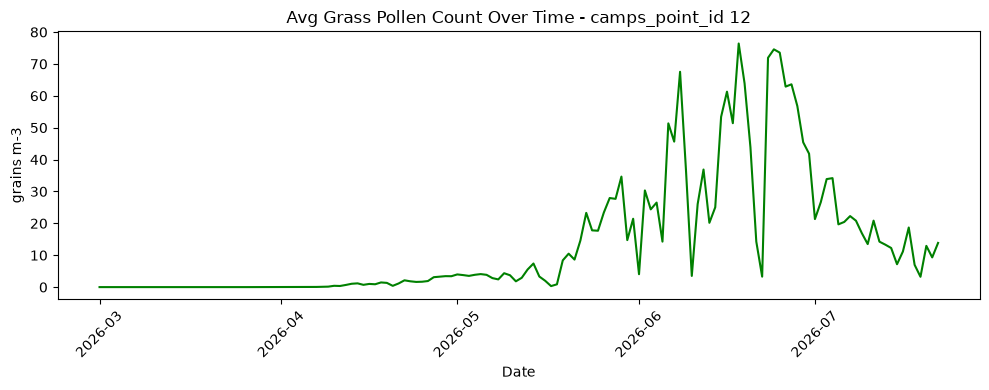

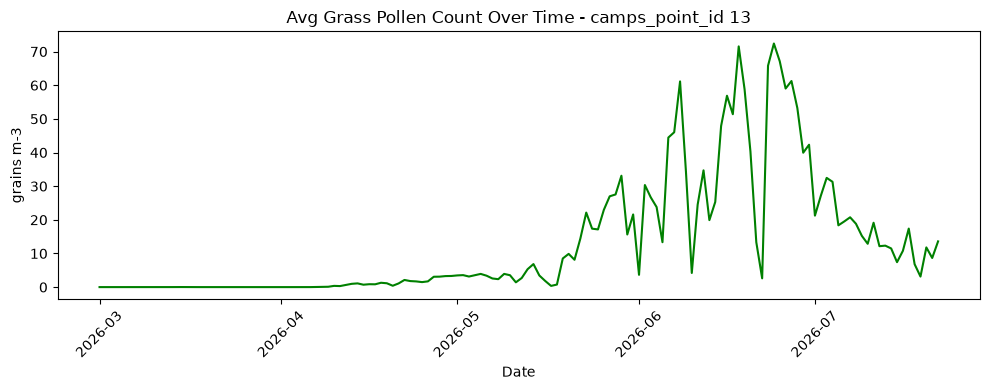

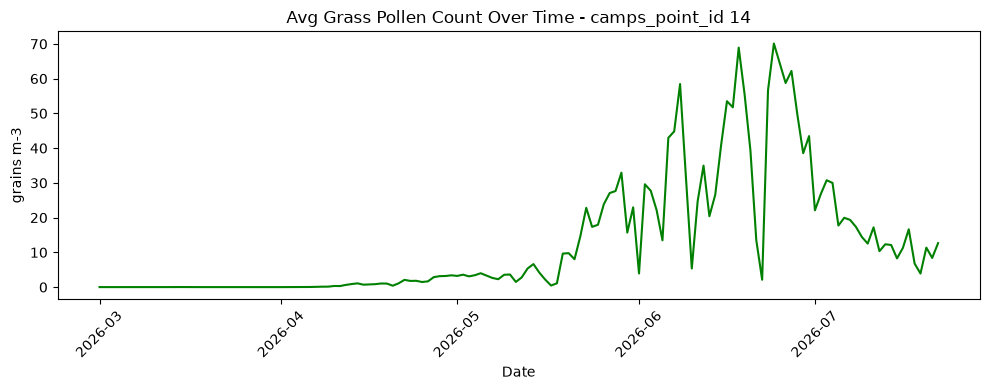

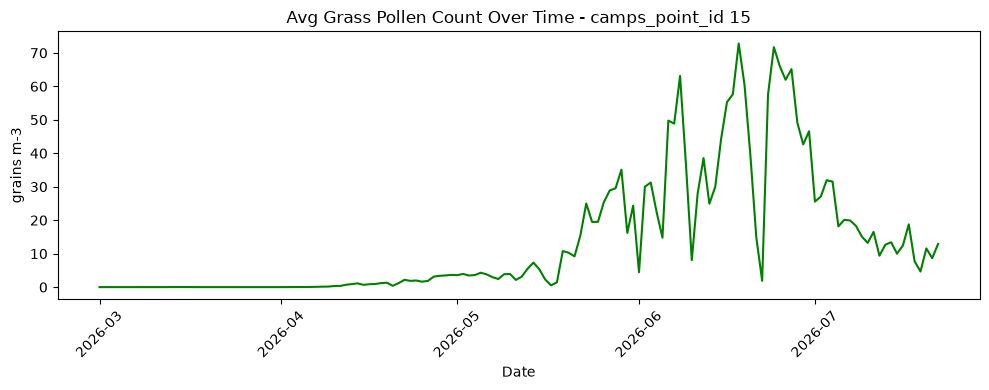

In [7]:
%matplotlib inline

site_ids = sorted(pd.to_numeric(df['camps_point_id'], errors='coerce').dropna().astype(int).unique())

for site_id in site_ids:
    site_series = (
        df_grouped.xs(site_id, level='camps_point_id')['grass_pollen']
        .sort_index()
    )
    plt.figure(figsize=(10, 4))
    plt.plot(site_series.index, site_series.values, color='g')
    plt.title(f"Avg Grass Pollen Count Over Time - camps_point_id {site_id}")
    plt.xlabel("Date")
    plt.xticks(rotation=45)
    plt.ylabel("grains m-3")
    plt.tight_layout()
    plt.show()

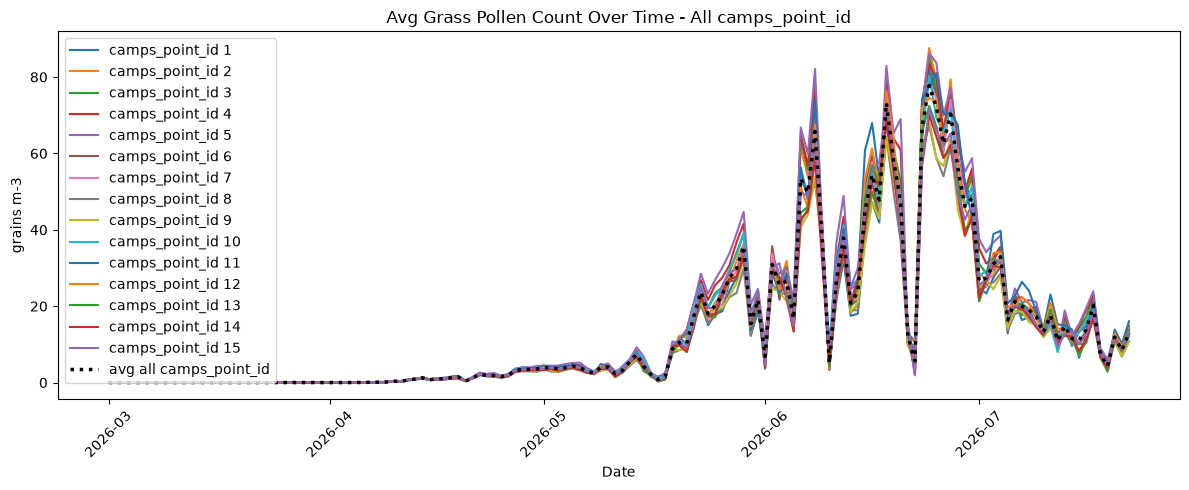

In [8]:
%matplotlib inline

plt.figure(figsize=(12, 5))

overall_avg = (
    df_grouped.groupby(level='fdate')['grass_pollen']
    .mean()
    .sort_index()
)

for site_id in site_ids:
    site_series = (
        df_grouped.xs(site_id, level='camps_point_id')['grass_pollen']
        .sort_index()
    )
    plt.plot(
        site_series.index,
        site_series.values,
        label=f'camps_point_id {site_id}',
        zorder=1
    )

plt.plot(
    overall_avg.index,
    overall_avg.values,
    label='avg all camps_point_id',
    linewidth=2.5,
    color='black',
    linestyle=':',
    zorder=2
)

plt.title('Avg Grass Pollen Count Over Time - All camps_point_id')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.ylabel('grains m-3')
plt.legend(loc='upper left', bbox_to_anchor=(0.0, 1.0))
plt.tight_layout()
plt.show()

In [9]:
df_grouped_time = (
    df.groupby(['fdate', 'ftime'], as_index=False)[
        ['alder_pollen', 'birch_pollen', 'grass_pollen', 'mugwort_pollen', 'olive_pollen', 'ragweed_pollen', 'pollen_total']
    ].mean()
)
df_grouped_time.tail(10)


,fdate,ftime,alder_pollen,birch_pollen,grass_pollen,mugwort_pollen,olive_pollen,ragweed_pollen,pollen_total
3446,2026-07-22,14:00:00,0.000,0.000,9.901,4.402,0.000,0.000,14.303
3447,2026-07-22,15:00:00,0.000,0.000,11.277,4.560,0.000,0.000,15.837
3448,2026-07-22,16:00:00,0.000,0.000,13.889,4.828,0.000,0.000,18.717
3449,2026-07-22,17:00:00,0.000,0.000,16.345,5.156,0.000,0.000,21.501
3450,2026-07-22,18:00:00,0.000,0.000,18.755,5.325,0.000,0.000,24.080
3451,2026-07-22,19:00:00,0.000,0.000,21.419,6.455,0.000,0.000,27.874
3452,2026-07-22,20:00:00,0.000,0.000,22.904,8.238,0.000,0.000,31.142
3453,2026-07-22,21:00:00,0.000,0.000,22.467,9.012,0.000,0.000,31.478
3454,2026-07-22,22:00:00,0.000,0.000,22.113,9.048,0.000,0.000,31.161
3455,2026-07-22,23:00:00,0.000,0.000,19.774,7.643,0.000,0.000,27.417


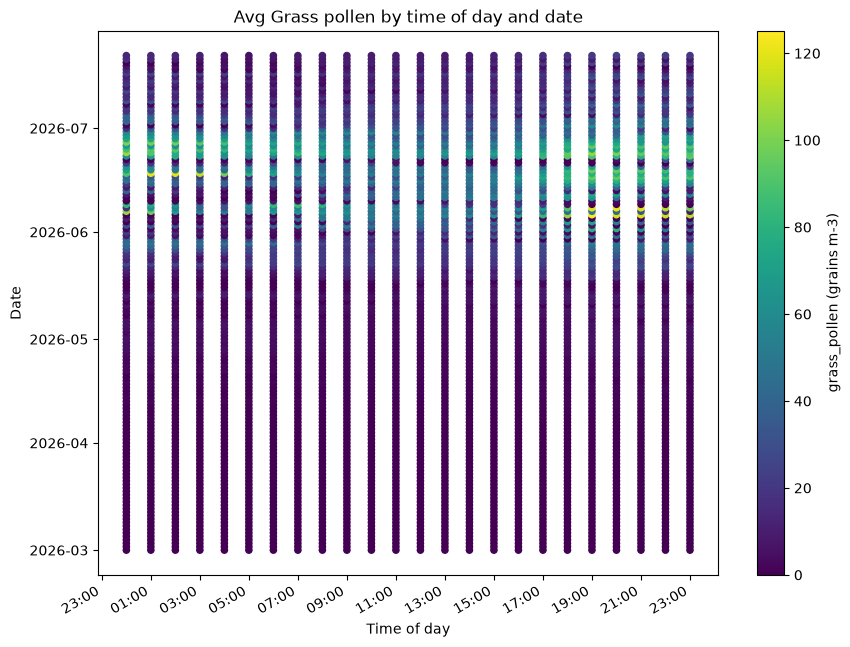

In [10]:
# Scatter plot: x = ftime (time of day), y = fdate (date), color = grass_pollen

ftimes = pd.to_datetime(df_grouped_time['ftime'].astype(str), format='%H:%M:%S', errors='coerce')
fdates = df_grouped_time['fdate']

plt.figure(figsize=(10, 8))
sc = plt.scatter(ftimes, fdates, c=df_grouped_time['grass_pollen'], cmap='viridis', s=20)
plt.colorbar(sc, label='grass_pollen (grains m-3)')
plt.xlabel('Time of day')
plt.ylabel('Date')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.gcf().autofmt_xdate()
plt.title(f'Avg Grass pollen by time of day and date')
plt.show()


In [11]:
engine_render = create_engine(get_database_render_url(), pool_pre_ping=True)
df_synop = pd.read_sql(
    """SELECT * FROM public.synop_data
    ORDER BY date DESC, measurement_hour ASC """,
    engine_render
)

df_synop.head()

,station_id,date,measurement_hour,date_add,date_update,station_name,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure
0,12566,2026-07-22,0,2026-07-22 01:00:48.240800,2026-07-22 01:00:48.238594,Kraków,13.700,3.000,270,84.600,0.000,1019.100
1,12566,2026-07-22,1,2026-07-22 02:00:37.223877,2026-07-22 02:00:37.221961,Kraków,12.500,2.000,270,86.800,0.000,1019.200
2,12566,2026-07-22,2,2026-07-22 03:01:08.196730,2026-07-22 03:01:08.195883,Kraków,12.200,1.000,220,89.800,0.000,1019.200
3,12566,2026-07-22,3,2026-07-22 04:00:52.717271,2026-07-22 04:00:52.715065,Kraków,11.700,2.000,220,91.600,0.000,1019.200
4,12566,2026-07-22,4,2026-07-22 05:00:59.178521,2026-07-22 05:00:59.179304,Kraków,11.900,1.000,200,88.000,0.000,1019.100


In [12]:
df_synop.dtypes

station_id                    int64
date                         object
measurement_hour              int64
date_add             datetime64[us]
date_update          datetime64[us]
station_name                    str
temperature                 float64
wind_speed                  float64
wind_direction                int64
relative_humidity           float64
rainfall_sum                float64
pressure                    float64
dtype: object

In [13]:
df_synop['date'] = pd.to_datetime(df_synop['date'], format='%Y-%m-%d')
df_synop['measurement_hour_dt'] = df_synop['date'] + pd.to_timedelta(df_synop['measurement_hour'], unit='h')
df_synop['measurement_hour'] = df_synop['measurement_hour_dt'].dt.time

df_synop['date_N_h_ahead'] = df_synop['measurement_hour_dt'] + pd.Timedelta(hours=12)

In [14]:
df_synop.head(5)

,station_id,date,measurement_hour,date_add,date_update,station_name,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,measurement_hour_dt,date_N_h_ahead
0,12566,2026-07-22,00:00:00,2026-07-22 01:00:48.240800,2026-07-22 01:00:48.238594,Kraków,13.700,3.000,270,84.600,0.000,1019.100,2026-07-22 00:00:00,2026-07-22 12:00:00
1,12566,2026-07-22,01:00:00,2026-07-22 02:00:37.223877,2026-07-22 02:00:37.221961,Kraków,12.500,2.000,270,86.800,0.000,1019.200,2026-07-22 01:00:00,2026-07-22 13:00:00
2,12566,2026-07-22,02:00:00,2026-07-22 03:01:08.196730,2026-07-22 03:01:08.195883,Kraków,12.200,1.000,220,89.800,0.000,1019.200,2026-07-22 02:00:00,2026-07-22 14:00:00
3,12566,2026-07-22,03:00:00,2026-07-22 04:00:52.717271,2026-07-22 04:00:52.715065,Kraków,11.700,2.000,220,91.600,0.000,1019.200,2026-07-22 03:00:00,2026-07-22 15:00:00
4,12566,2026-07-22,04:00:00,2026-07-22 05:00:59.178521,2026-07-22 05:00:59.179304,Kraków,11.900,1.000,200,88.000,0.000,1019.100,2026-07-22 04:00:00,2026-07-22 16:00:00


In [67]:
df_synop_filtered = df_synop[['date', 'date_N_h_ahead', 'measurement_hour', 'measurement_hour_dt', 'temperature', 'wind_speed', 'wind_direction', 'relative_humidity', 'rainfall_sum', 'pressure']].copy()
df_synop_filtered.head(24)

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure
0,2026-07-22,2026-07-22 12:00:00,00:00:00,2026-07-22 00:00:00,13.700,3.000,270,84.600,0.000,1019.100
1,2026-07-22,2026-07-22 13:00:00,01:00:00,2026-07-22 01:00:00,12.500,2.000,270,86.800,0.000,1019.200
2,2026-07-22,2026-07-22 14:00:00,02:00:00,2026-07-22 02:00:00,12.200,1.000,220,89.800,0.000,1019.200
3,2026-07-22,2026-07-22 15:00:00,03:00:00,2026-07-22 03:00:00,11.700,2.000,220,91.600,0.000,1019.200
4,2026-07-22,2026-07-22 16:00:00,04:00:00,2026-07-22 04:00:00,11.900,1.000,200,88.000,0.000,1019.100
5,2026-07-22,2026-07-22 17:00:00,05:00:00,2026-07-22 05:00:00,12.900,2.000,210,84.600,0.000,1019.000
6,2026-07-22,2026-07-22 18:00:00,06:00:00,2026-07-22 06:00:00,15.200,3.000,220,77.700,0.100,1018.700
7,2026-07-22,2026-07-22 19:00:00,07:00:00,2026-07-22 07:00:00,17.000,3.000,200,67.300,0.100,1018.400
8,2026-07-22,2026-07-22 20:00:00,08:00:00,2026-07-22 08:00:00,17.300,2.000,230,61.300,0.100,1018.200
9,2026-07-22,2026-07-22 21:00:00,09:00:00,2026-07-22 09:00:00,18.200,4.000,270,54.400,0.100,1018.000


In [68]:
df_synop_filtered['date_date_ahead'] = df_synop_filtered['date_N_h_ahead'].dt.date.copy()
df_synop_filtered['time_date_ahead'] = df_synop_filtered['date_N_h_ahead'].dt.time.copy()
df_synop_filtered['date_date_ahead'] = pd.to_datetime(df_synop_filtered['date_date_ahead'], format='%Y-%m-%d')
df_synop_filtered.head(24)

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead
0,2026-07-22,2026-07-22 12:00:00,00:00:00,2026-07-22 00:00:00,13.700,3.000,270,84.600,0.000,1019.100,2026-07-22,12:00:00
1,2026-07-22,2026-07-22 13:00:00,01:00:00,2026-07-22 01:00:00,12.500,2.000,270,86.800,0.000,1019.200,2026-07-22,13:00:00
2,2026-07-22,2026-07-22 14:00:00,02:00:00,2026-07-22 02:00:00,12.200,1.000,220,89.800,0.000,1019.200,2026-07-22,14:00:00
3,2026-07-22,2026-07-22 15:00:00,03:00:00,2026-07-22 03:00:00,11.700,2.000,220,91.600,0.000,1019.200,2026-07-22,15:00:00
4,2026-07-22,2026-07-22 16:00:00,04:00:00,2026-07-22 04:00:00,11.900,1.000,200,88.000,0.000,1019.100,2026-07-22,16:00:00
5,2026-07-22,2026-07-22 17:00:00,05:00:00,2026-07-22 05:00:00,12.900,2.000,210,84.600,0.000,1019.000,2026-07-22,17:00:00
6,2026-07-22,2026-07-22 18:00:00,06:00:00,2026-07-22 06:00:00,15.200,3.000,220,77.700,0.100,1018.700,2026-07-22,18:00:00
7,2026-07-22,2026-07-22 19:00:00,07:00:00,2026-07-22 07:00:00,17.000,3.000,200,67.300,0.100,1018.400,2026-07-22,19:00:00
8,2026-07-22,2026-07-22 20:00:00,08:00:00,2026-07-22 08:00:00,17.300,2.000,230,61.300,0.100,1018.200,2026-07-22,20:00:00
9,2026-07-22,2026-07-22 21:00:00,09:00:00,2026-07-22 09:00:00,18.200,4.000,270,54.400,0.100,1018.000,2026-07-22,21:00:00


In [69]:
df_synop_mean_by_date = df_synop_filtered.groupby('date', as_index=False)[[ 'temperature', 'wind_speed', 'wind_direction', 'relative_humidity', 'rainfall_sum', 'pressure']].mean()
df_synop_mean_by_date.tail()

,date,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure
127,2026-07-18,20.375,2.917,213.333,80.850,3.150,1011.325
128,2026-07-19,19.292,2.542,176.250,78.483,2.250,1013.554
129,2026-07-20,17.238,4.250,249.583,64.429,7.975,1017.654
130,2026-07-21,15.833,4.917,250.833,71.275,2.525,1018.800
131,2026-07-22,15.723,2.692,233.846,70.531,0.054,1018.454


In [70]:
df_merged = df_synop_filtered.merge(
    df_grouped_time[['fdate', 'ftime', 'grass_pollen']].rename(columns={'fdate': 'date', 'ftime': 'measurement_hour'}),
    on=['date', 'measurement_hour'],
    how='left'
)
df_merged.head(24)

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen
0,2026-07-22,2026-07-22 12:00:00,00:00:00,2026-07-22 00:00:00,13.700,3.000,270,84.600,0.000,1019.100,2026-07-22,12:00:00,13.207
1,2026-07-22,2026-07-22 13:00:00,01:00:00,2026-07-22 01:00:00,12.500,2.000,270,86.800,0.000,1019.200,2026-07-22,13:00:00,13.815
2,2026-07-22,2026-07-22 14:00:00,02:00:00,2026-07-22 02:00:00,12.200,1.000,220,89.800,0.000,1019.200,2026-07-22,14:00:00,13.047
3,2026-07-22,2026-07-22 15:00:00,03:00:00,2026-07-22 03:00:00,11.700,2.000,220,91.600,0.000,1019.200,2026-07-22,15:00:00,10.472
4,2026-07-22,2026-07-22 16:00:00,04:00:00,2026-07-22 04:00:00,11.900,1.000,200,88.000,0.000,1019.100,2026-07-22,16:00:00,7.327
5,2026-07-22,2026-07-22 17:00:00,05:00:00,2026-07-22 05:00:00,12.900,2.000,210,84.600,0.000,1019.000,2026-07-22,17:00:00,5.618
6,2026-07-22,2026-07-22 18:00:00,06:00:00,2026-07-22 06:00:00,15.200,3.000,220,77.700,0.100,1018.700,2026-07-22,18:00:00,7.203
7,2026-07-22,2026-07-22 19:00:00,07:00:00,2026-07-22 07:00:00,17.000,3.000,200,67.300,0.100,1018.400,2026-07-22,19:00:00,8.500
8,2026-07-22,2026-07-22 20:00:00,08:00:00,2026-07-22 08:00:00,17.300,2.000,230,61.300,0.100,1018.200,2026-07-22,20:00:00,9.090
9,2026-07-22,2026-07-22 21:00:00,09:00:00,2026-07-22 09:00:00,18.200,4.000,270,54.400,0.100,1018.000,2026-07-22,21:00:00,8.995


In [71]:
df_merged_mean_temperature_by_date = df_merged.merge(
    df_synop_mean_by_date[['date', 'temperature']].rename(columns={'temperature': 'avg_day_temperature'}),
    on=['date'],
    how='left'
)
df_merged_mean_temperature_by_date.head()

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature
0,2026-07-22,2026-07-22 12:00:00,00:00:00,2026-07-22 00:00:00,13.700,3.000,270,84.600,0.000,1019.100,2026-07-22,12:00:00,13.207,15.723
1,2026-07-22,2026-07-22 13:00:00,01:00:00,2026-07-22 01:00:00,12.500,2.000,270,86.800,0.000,1019.200,2026-07-22,13:00:00,13.815,15.723
2,2026-07-22,2026-07-22 14:00:00,02:00:00,2026-07-22 02:00:00,12.200,1.000,220,89.800,0.000,1019.200,2026-07-22,14:00:00,13.047,15.723
3,2026-07-22,2026-07-22 15:00:00,03:00:00,2026-07-22 03:00:00,11.700,2.000,220,91.600,0.000,1019.200,2026-07-22,15:00:00,10.472,15.723
4,2026-07-22,2026-07-22 16:00:00,04:00:00,2026-07-22 04:00:00,11.900,1.000,200,88.000,0.000,1019.100,2026-07-22,16:00:00,7.327,15.723


In [74]:
# 5 AM to 9 PM = day, 10 PM to 4 AM = night
df_merged_mean_temperature_by_date['day_night'] = df_merged_mean_temperature_by_date['measurement_hour_dt'].apply(
    lambda x: 'day' if 5 <= x.hour <= 21 else 'night'
)

# Calculate average temperature per day/night period and map it back to each row
avg_day_temp = (
    df_merged_mean_temperature_by_date[df_merged_mean_temperature_by_date['day_night'] == 'day']
    .groupby('date')['temperature']
    .mean()
    .rename('avg_day_light_temperature')
)

avg_night_temp = (
    df_merged_mean_temperature_by_date[df_merged_mean_temperature_by_date['day_night'] == 'night']
    .groupby('date')['temperature']
    .mean()
    .rename('avg_night_temperature')
)

# Add the per-day averages as columns on the existing dataframe
df_merged_mean_temperature_by_date['avg_day_light_temperature'] = (
    df_merged_mean_temperature_by_date['date'].map(avg_day_temp)
)
df_merged_mean_temperature_by_date['avg_night_temperature'] = (
    df_merged_mean_temperature_by_date['date'].map(avg_night_temp)
)

# Add a single column representing the temperature for the current day/night period
# for each row, based on the same mapping logic
df_merged_mean_temperature_by_date['avg_day_night_temperature'] = np.where(
    df_merged_mean_temperature_by_date['day_night'] == 'day',
    df_merged_mean_temperature_by_date['avg_day_light_temperature'],
    df_merged_mean_temperature_by_date['avg_night_temperature']
)

df_merged_mean_temperature_by_date[['date', 'measurement_hour_dt', 'day_night', 'temperature', 'avg_day_light_temperature', 'avg_day_temperature', 'avg_night_temperature', 'avg_day_night_temperature']].head(24)

,date,measurement_hour_dt,day_night,temperature,avg_day_light_temperature,avg_day_temperature,avg_night_temperature,avg_day_night_temperature
0,2026-07-22,2026-07-22 00:00:00,night,13.700,17.800,15.723,12.400,12.400
1,2026-07-22,2026-07-22 01:00:00,night,12.500,17.800,15.723,12.400,12.400
2,2026-07-22,2026-07-22 02:00:00,night,12.200,17.800,15.723,12.400,12.400
3,2026-07-22,2026-07-22 03:00:00,night,11.700,17.800,15.723,12.400,12.400
4,2026-07-22,2026-07-22 04:00:00,night,11.900,17.800,15.723,12.400,12.400
5,2026-07-22,2026-07-22 05:00:00,day,12.900,17.800,15.723,12.400,17.800
6,2026-07-22,2026-07-22 06:00:00,day,15.200,17.800,15.723,12.400,17.800
7,2026-07-22,2026-07-22 07:00:00,day,17.000,17.800,15.723,12.400,17.800
8,2026-07-22,2026-07-22 08:00:00,day,17.300,17.800,15.723,12.400,17.800
9,2026-07-22,2026-07-22 09:00:00,day,18.200,17.800,15.723,12.400,17.800


In [75]:
df_merged_mean_temperature_by_date.drop(columns=['avg_day_light_temperature', 'avg_night_temperature'], inplace=True)
df_merged_mean_temperature_by_date.head(24)

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature,day_night,avg_day_night_temperature
0,2026-07-22,2026-07-22 12:00:00,00:00:00,2026-07-22 00:00:00,13.700,3.000,270,84.600,0.000,1019.100,2026-07-22,12:00:00,13.207,15.723,night,12.400
1,2026-07-22,2026-07-22 13:00:00,01:00:00,2026-07-22 01:00:00,12.500,2.000,270,86.800,0.000,1019.200,2026-07-22,13:00:00,13.815,15.723,night,12.400
2,2026-07-22,2026-07-22 14:00:00,02:00:00,2026-07-22 02:00:00,12.200,1.000,220,89.800,0.000,1019.200,2026-07-22,14:00:00,13.047,15.723,night,12.400
3,2026-07-22,2026-07-22 15:00:00,03:00:00,2026-07-22 03:00:00,11.700,2.000,220,91.600,0.000,1019.200,2026-07-22,15:00:00,10.472,15.723,night,12.400
4,2026-07-22,2026-07-22 16:00:00,04:00:00,2026-07-22 04:00:00,11.900,1.000,200,88.000,0.000,1019.100,2026-07-22,16:00:00,7.327,15.723,night,12.400
5,2026-07-22,2026-07-22 17:00:00,05:00:00,2026-07-22 05:00:00,12.900,2.000,210,84.600,0.000,1019.000,2026-07-22,17:00:00,5.618,15.723,day,17.800
6,2026-07-22,2026-07-22 18:00:00,06:00:00,2026-07-22 06:00:00,15.200,3.000,220,77.700,0.100,1018.700,2026-07-22,18:00:00,7.203,15.723,day,17.800
7,2026-07-22,2026-07-22 19:00:00,07:00:00,2026-07-22 07:00:00,17.000,3.000,200,67.300,0.100,1018.400,2026-07-22,19:00:00,8.500,15.723,day,17.800
8,2026-07-22,2026-07-22 20:00:00,08:00:00,2026-07-22 08:00:00,17.300,2.000,230,61.300,0.100,1018.200,2026-07-22,20:00:00,9.090,15.723,day,17.800
9,2026-07-22,2026-07-22 21:00:00,09:00:00,2026-07-22 09:00:00,18.200,4.000,270,54.400,0.100,1018.000,2026-07-22,21:00:00,8.995,15.723,day,17.800


In [20]:
df_merged_date_ahead = df_synop_filtered.merge(
    df_grouped_time[['fdate', 'ftime', 'grass_pollen']].rename(columns={'fdate': 'date_date_ahead', 'ftime': 'time_date_ahead'}),
    on=['date_date_ahead', 'time_date_ahead'],
    how='left'
)
df_merged_date_ahead.tail(50)

,date,date_N_h_ahead,measurement_hour,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen
3068,2026-03-15,2026-03-15 22:00:00,10:00:00,17.500,1.000,90,31.500,0.000,1011.700,2026-03-15,22:00:00,0.005
3069,2026-03-15,2026-03-15 23:00:00,11:00:00,18.800,1.000,180,29.400,0.000,1011.600,2026-03-15,23:00:00,0.005
3070,2026-03-15,2026-03-16 00:00:00,12:00:00,18.100,3.000,60,28.600,0.000,1011.300,2026-03-16,00:00:00,0.006
3071,2026-03-15,2026-03-16 01:00:00,13:00:00,17.900,3.000,110,29.600,0.000,1011.300,2026-03-16,01:00:00,0.006
3072,2026-03-15,2026-03-16 02:00:00,14:00:00,17.000,3.000,60,31.600,0.000,1011.400,2026-03-16,02:00:00,0.006
3073,2026-03-15,2026-03-16 03:00:00,15:00:00,17.400,3.000,40,28.600,0.000,1011.300,2026-03-16,03:00:00,0.007
3074,2026-03-15,2026-03-16 04:00:00,16:00:00,16.000,3.000,10,32.500,0.000,1011.800,2026-03-16,04:00:00,0.008
3075,2026-03-15,2026-03-16 05:00:00,17:00:00,13.800,4.000,330,45.600,0.000,1012.500,2026-03-16,05:00:00,0.009
3076,2026-03-15,2026-03-16 06:00:00,18:00:00,12.900,5.000,340,50.600,0.000,1013.100,2026-03-16,06:00:00,0.011
3077,2026-03-15,2026-03-16 07:00:00,19:00:00,11.000,4.000,50,62.500,0.000,1014.000,2026-03-16,07:00:00,0.011


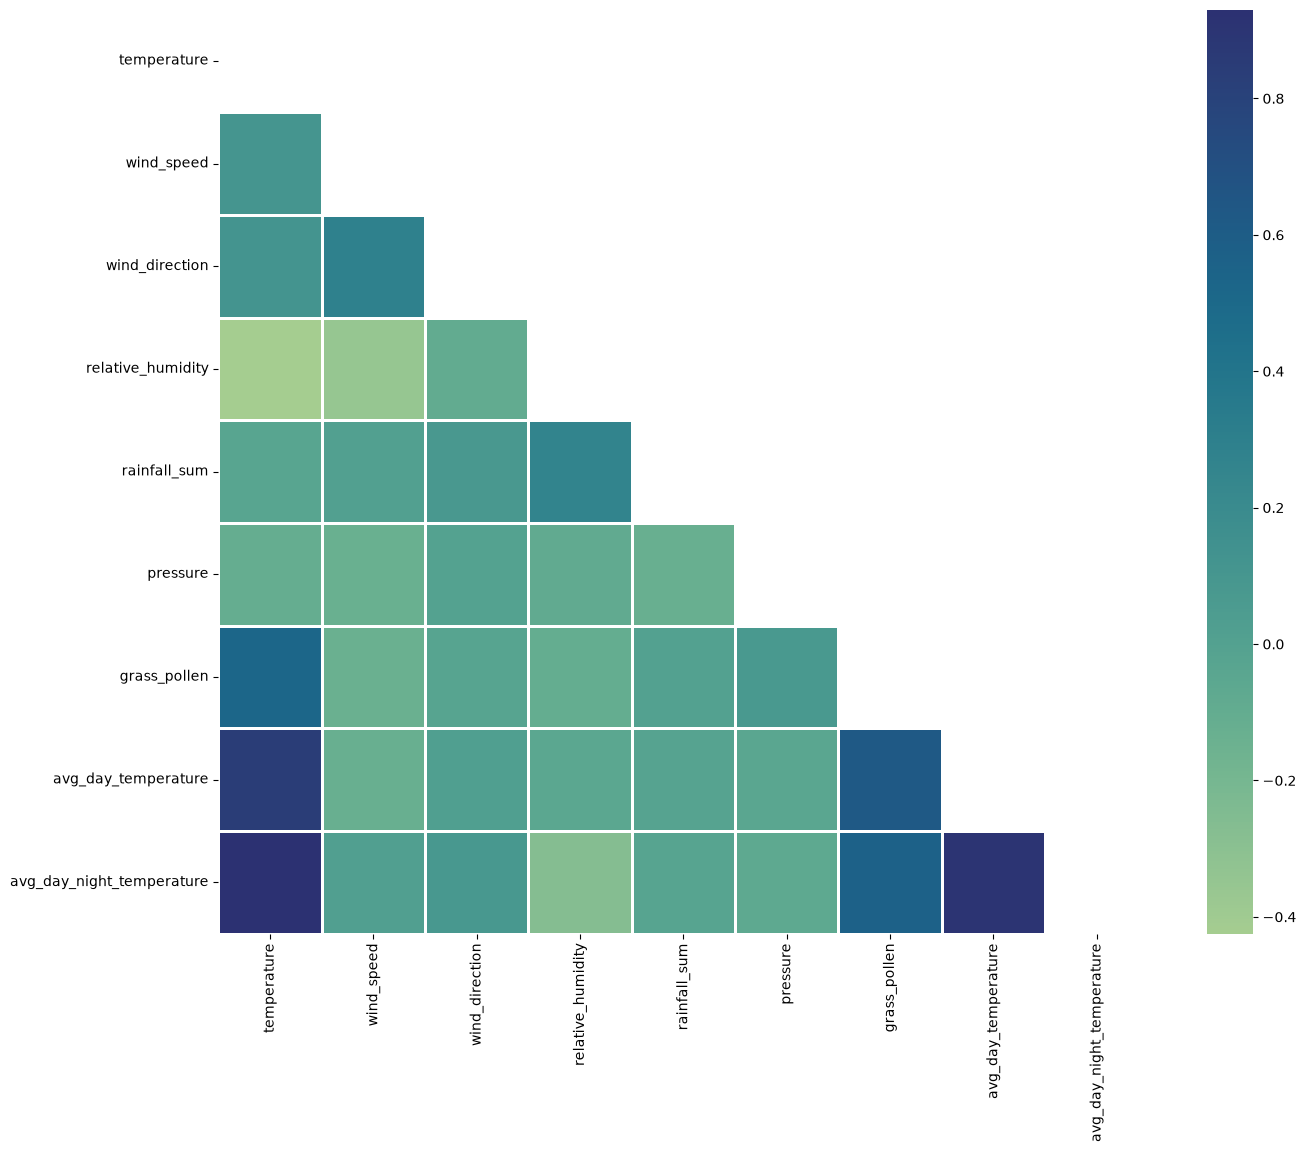

In [76]:
#triangular matrix
num_cols = df_merged_mean_temperature_by_date.select_dtypes(['int', 'float']).columns
corr_data = df_merged_mean_temperature_by_date[num_cols]

corr_coef = corr_data.corr()
plt.figure(figsize=(15, 12))
matrix = np.triu(corr_coef)
sns.heatmap(corr_coef,linewidth=.8, mask = matrix, cmap="crest");

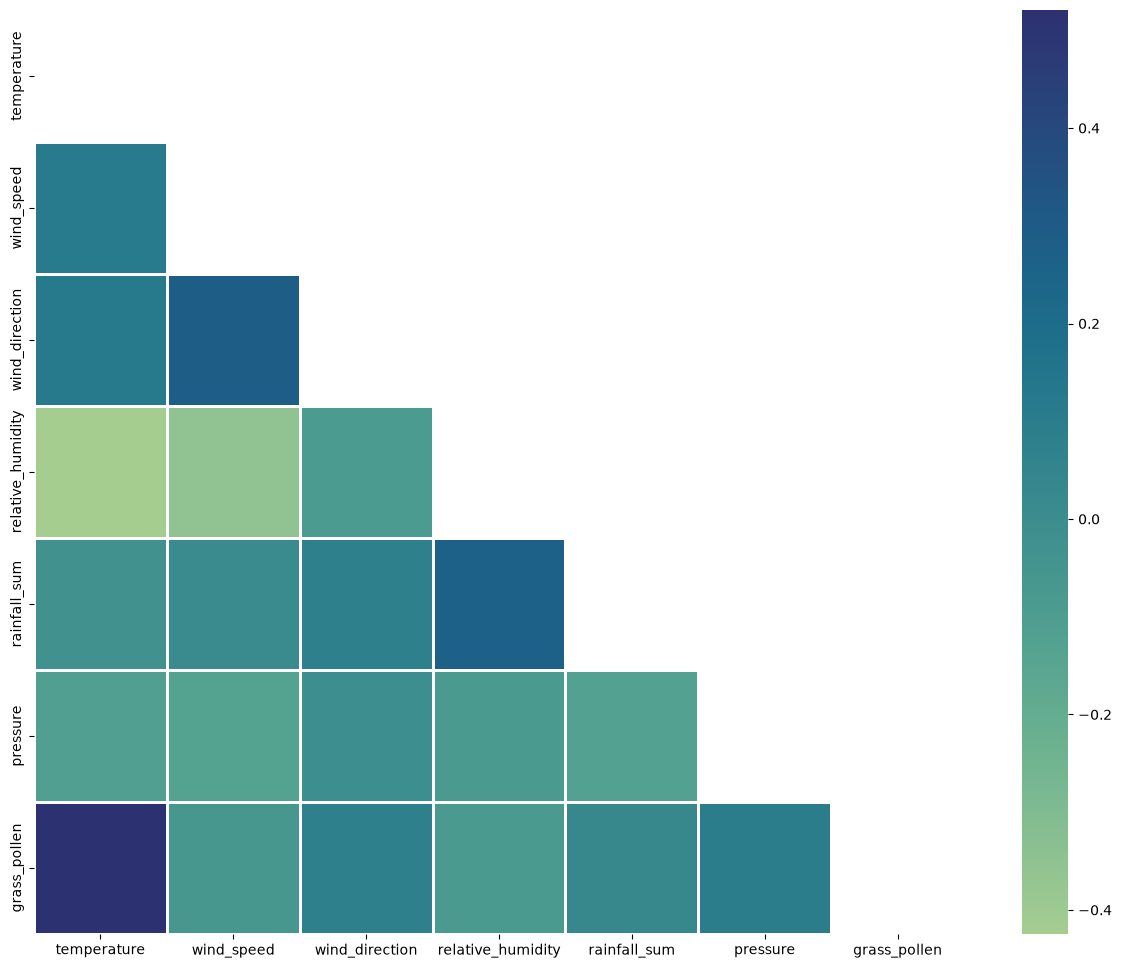

In [22]:
#triangular matrix date ahead
num_cols_date_ahead = df_merged_date_ahead.select_dtypes(['int', 'float']).columns
corr_data = df_merged_date_ahead[num_cols_date_ahead]

corr_coef_date_ahead = corr_data.corr()
plt.figure(figsize=(15, 12))
matrix = np.triu(corr_coef_date_ahead)
sns.heatmap(corr_coef_date_ahead,linewidth=.8, mask = matrix, cmap="crest");

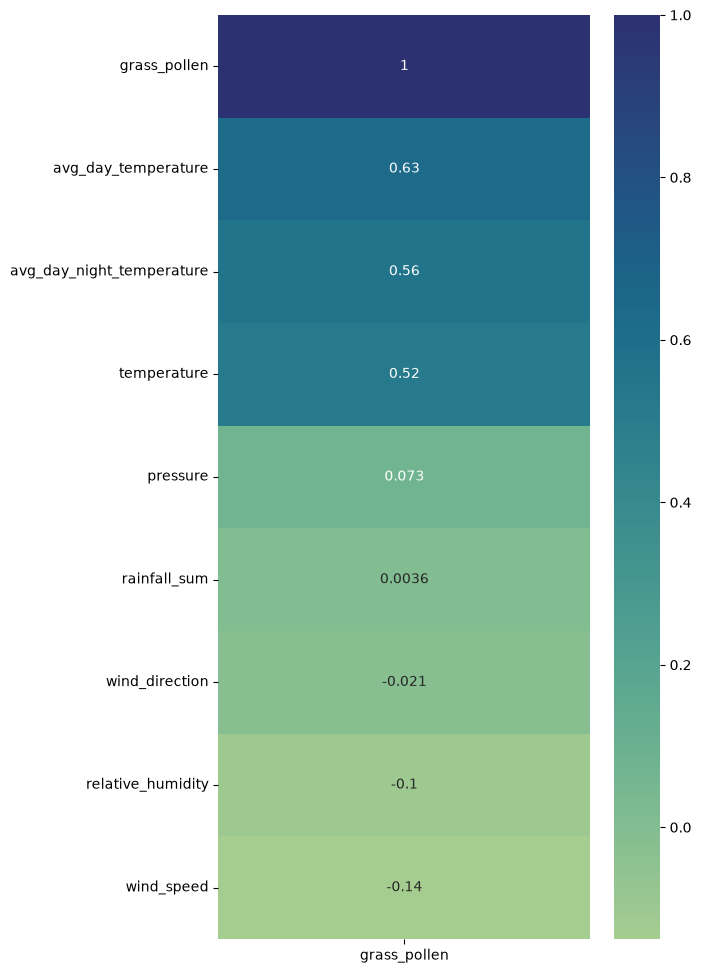

In [77]:
plt.figure(figsize=(6,12))
sns.heatmap(corr_coef[['grass_pollen']].sort_values(by=['grass_pollen'], ascending=False),
            cmap='crest',
            annot=True);

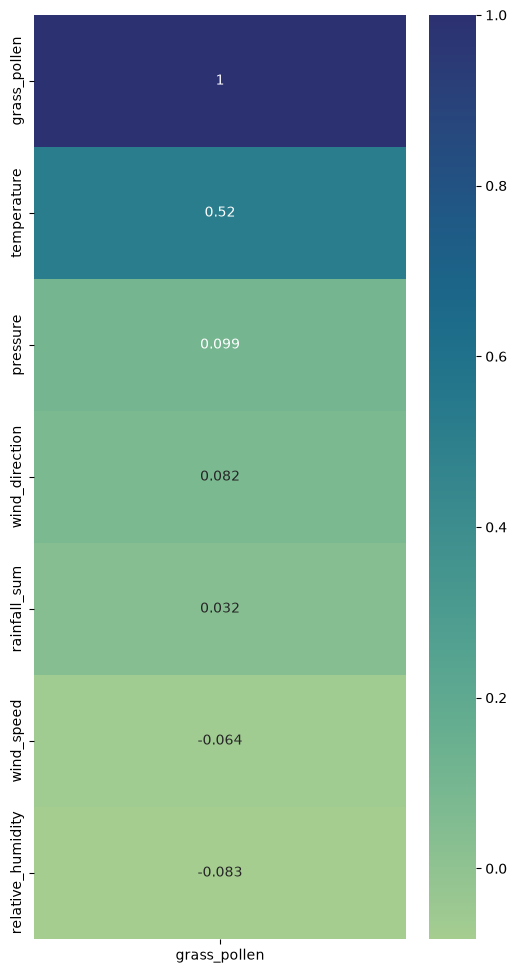

In [24]:
#date ahead
plt.figure(figsize=(6,12))
sns.heatmap(corr_coef_date_ahead[['grass_pollen']].sort_values(by=['grass_pollen'], ascending=False),
            cmap='crest',
            annot=True);


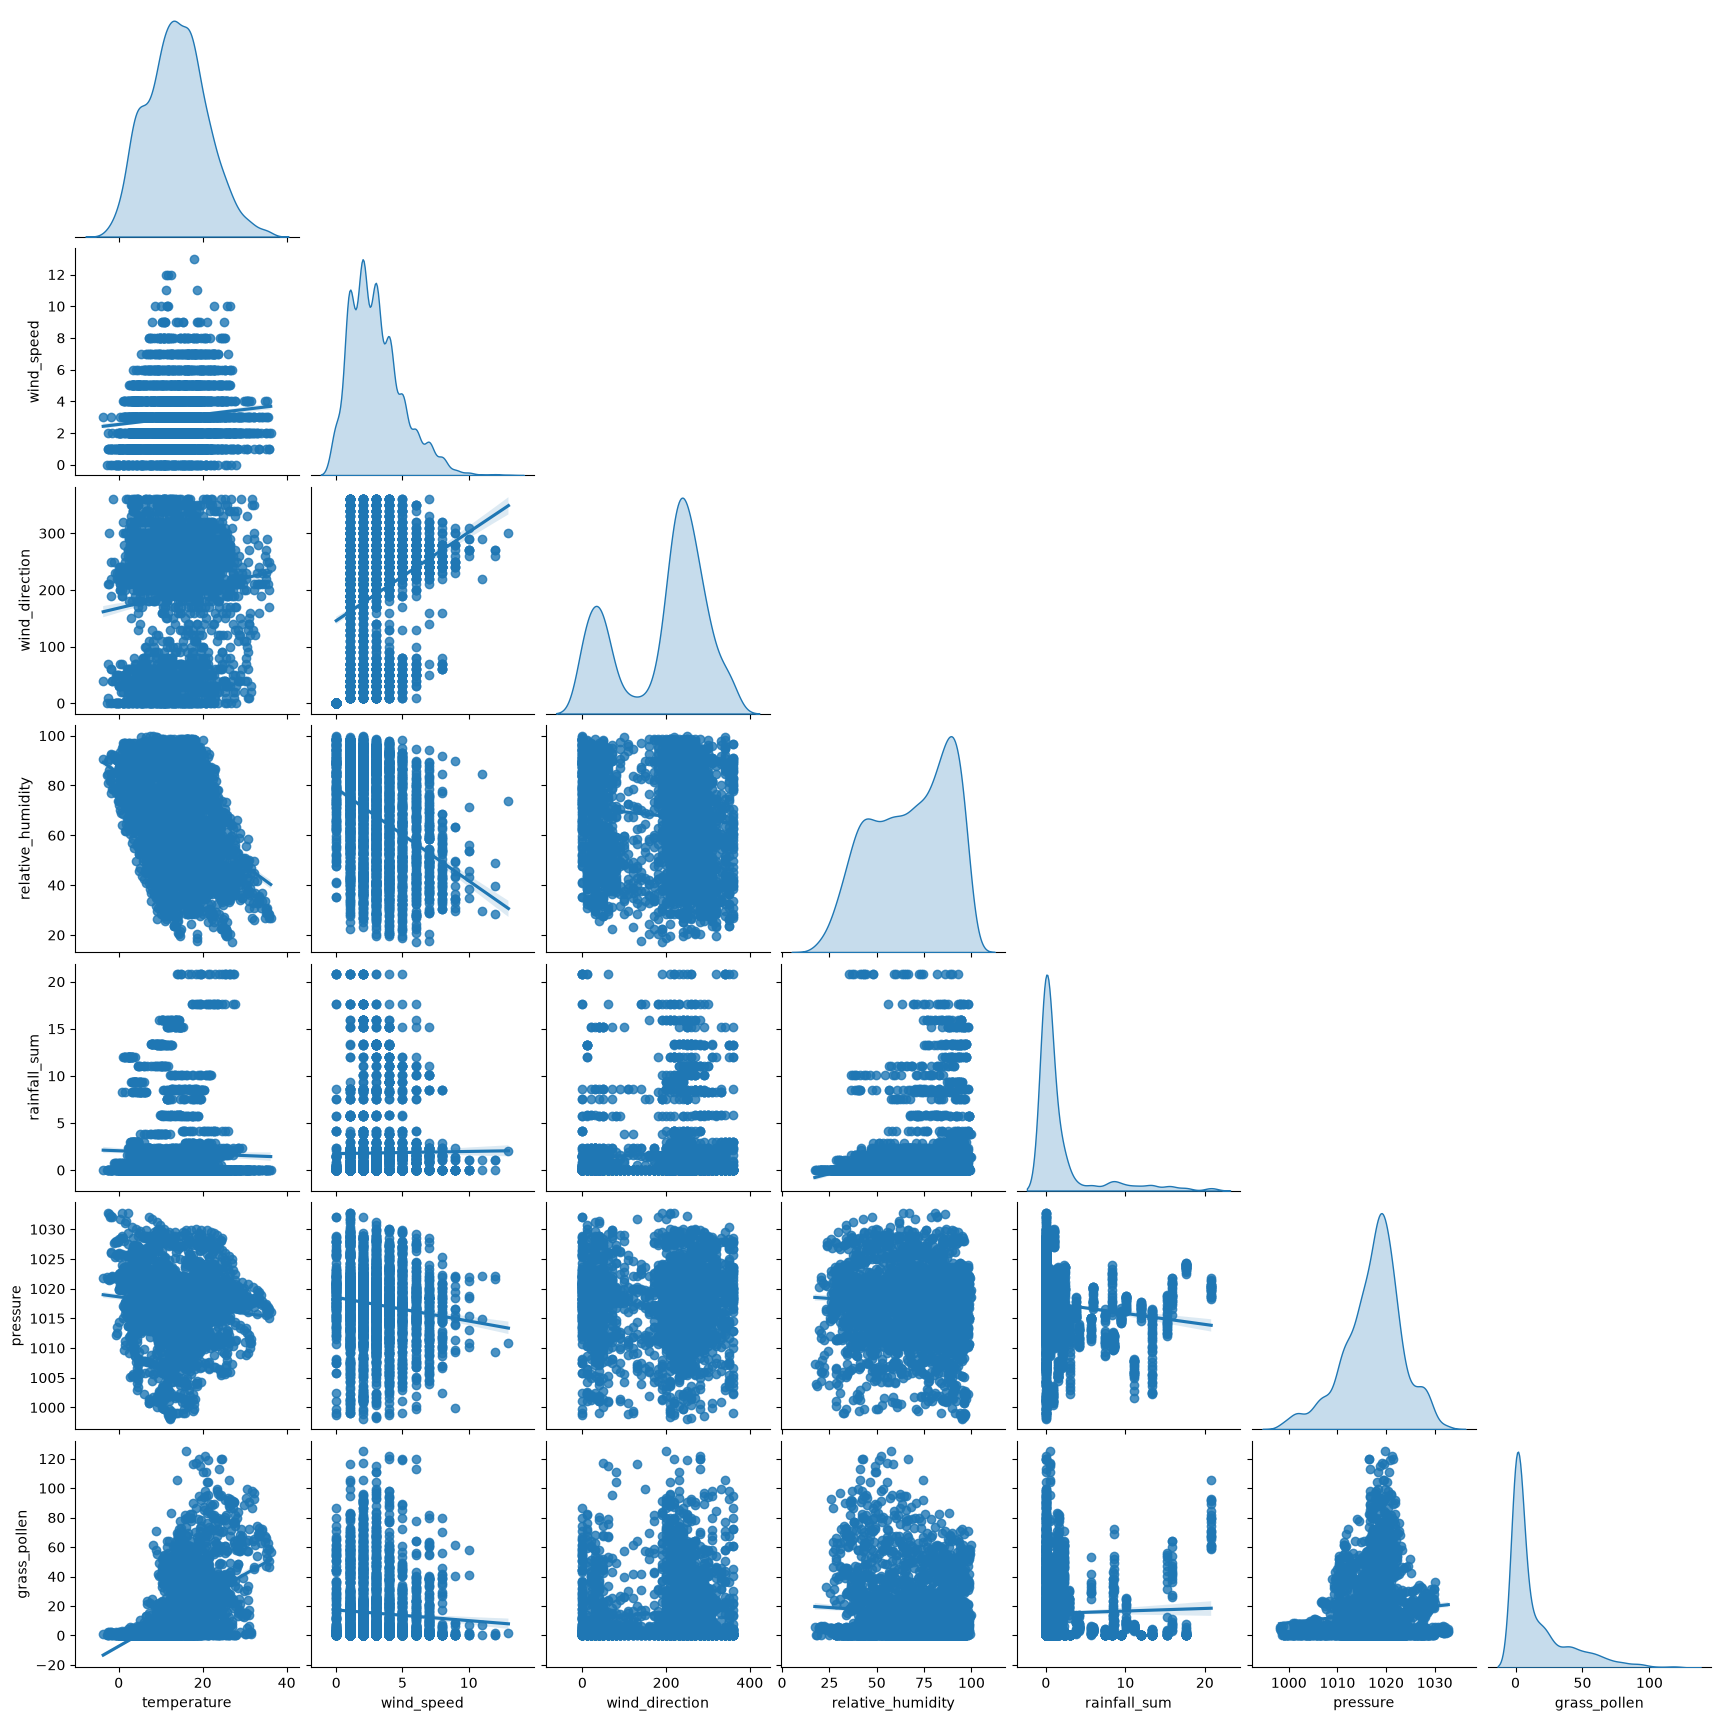

In [25]:
sns.pairplot(corr_data, corner=True, kind='reg', diag_kind='kde')

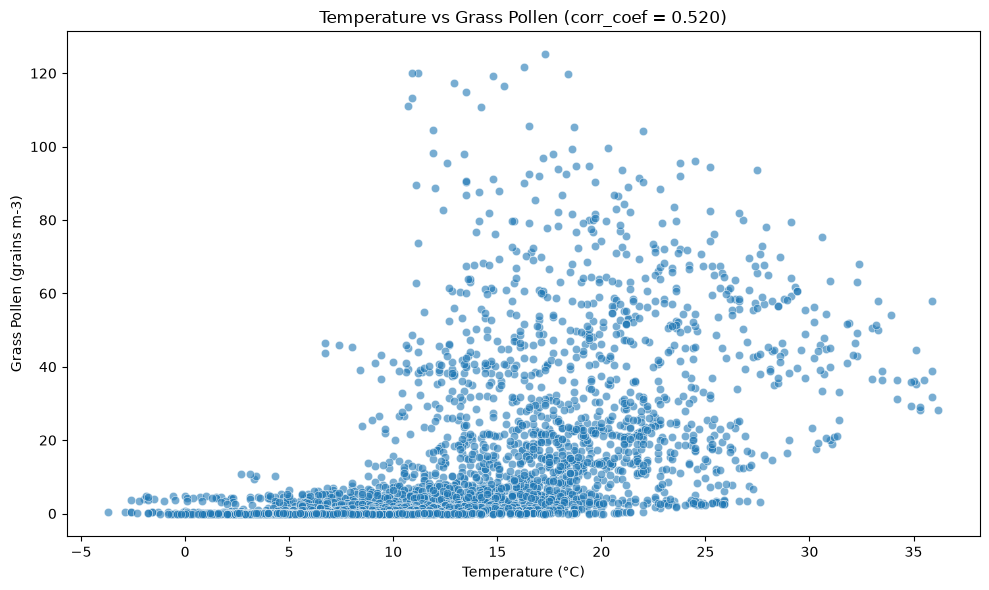

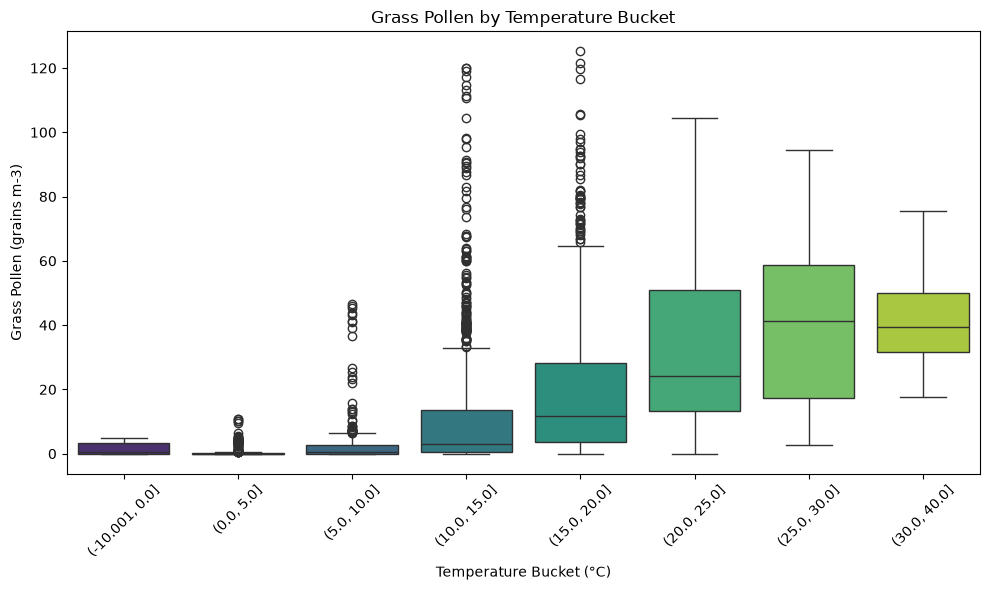

In [26]:
scatter_df = df_merged.dropna(subset=['temperature', 'grass_pollen']).copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=scatter_df, x='temperature', y='grass_pollen', alpha=0.6)
#sns.regplot(data=scatter_df, x='temperature', y='grass_pollen', scatter=False, color='black')
plt.title(f'Temperature vs Grass Pollen (corr_coef = {scatter_df[["temperature", "grass_pollen"]].corr().iloc[0, 1]:.3f})')
plt.xlabel('Temperature (°C)')
plt.ylabel('Grass Pollen (grains m-3)')
plt.tight_layout()
plt.show()

bucket_df = df_merged.dropna(subset=['temperature', 'grass_pollen']).copy()
bucket_df['temperature_bucket'] = pd.cut(
    bucket_df['temperature'],
    bins=[-10, 0, 5, 10, 15, 20, 25, 30, 40],
    right=True,
    include_lowest=True
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=bucket_df, x='temperature_bucket', y='grass_pollen', hue='temperature_bucket', dodge=False, legend=False, palette='viridis')
plt.title('Grass Pollen by Temperature Bucket')
plt.xlabel('Temperature Bucket (°C)')
plt.ylabel('Grass Pollen (grains m-3)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

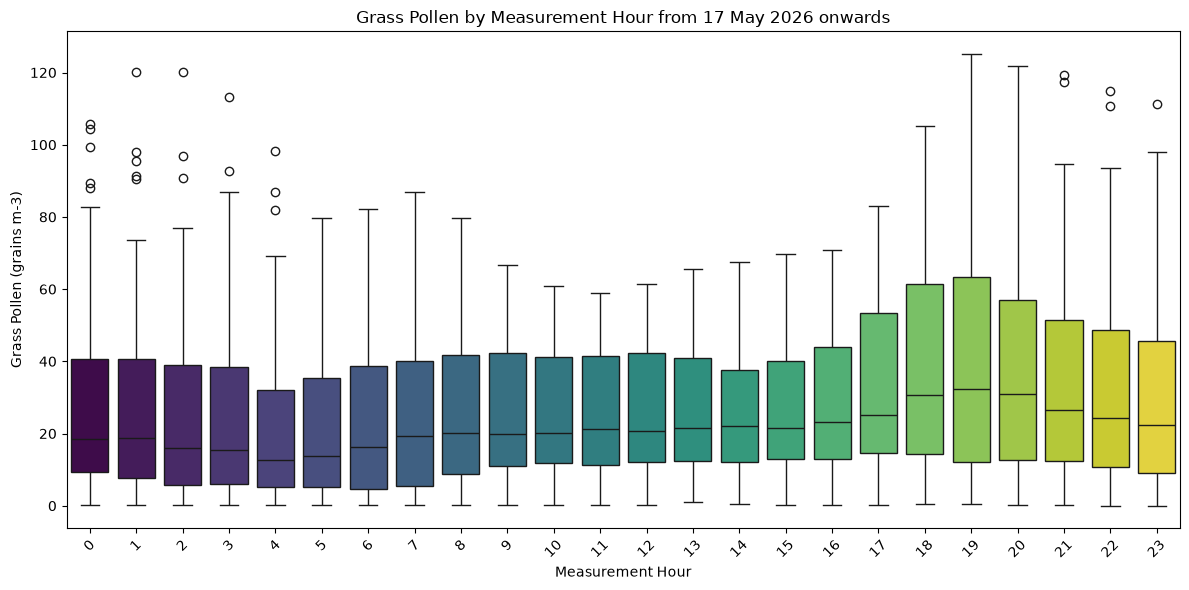

In [27]:
df_merged_from_date = df_merged[df_merged['date'] >= '2026-05-17'].copy()
hourly_df = df_merged_from_date.dropna(subset=['measurement_hour', 'grass_pollen']).copy()
hourly_df['measurement_hour'] = hourly_df['measurement_hour'].apply(lambda h: h.hour)

plt.figure(figsize=(12, 6))
sns.boxplot(data=hourly_df, x='measurement_hour', y='grass_pollen', hue='measurement_hour', dodge=False, legend=False, palette='viridis')
plt.title('Grass Pollen by Measurement Hour from 17 May 2026 onwards')
plt.xlabel('Measurement Hour')
plt.ylabel('Grass Pollen (grains m-3)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
df_merged_from_date_range_1 = df_merged_mean_temperature_by_date[(df_merged_mean_temperature_by_date['date'] >= '2026-05-28') & (df_merged_mean_temperature_by_date['date'] < '2026-06-05')].copy()
plot_df_1 = df_merged_from_date_range_1.sort_values(['date', 'measurement_hour'])
plot_df_1.head(60)

,date,date_N_h_ahead,measurement_hour,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature
1284,2026-05-28,2026-05-28 12:00:00,00:00:00,12.300,3.000,310,46.600,0.000,1020.100,2026-05-28,12:00:00,40.535,14.425
1285,2026-05-28,2026-05-28 13:00:00,01:00:00,11.700,3.000,310,48.500,0.000,1020.100,2026-05-28,13:00:00,40.131,14.425
1286,2026-05-28,2026-05-28 14:00:00,02:00:00,8.400,2.000,270,64.700,0.000,1020.600,2026-05-28,14:00:00,39.185,14.425
1287,2026-05-28,2026-05-28 15:00:00,03:00:00,9.400,1.000,230,61.700,0.000,1020.800,2026-05-28,15:00:00,36.672,14.425
1288,2026-05-28,2026-05-28 16:00:00,04:00:00,10.400,3.000,260,60.700,0.000,1021.200,2026-05-28,16:00:00,32.948,14.425
1289,2026-05-28,2026-05-28 17:00:00,05:00:00,12.200,4.000,290,54.500,0.000,1021.400,2026-05-28,17:00:00,28.696,14.425
1290,2026-05-28,2026-05-28 18:00:00,06:00:00,13.400,4.000,280,54.400,0.000,1021.700,2026-05-28,18:00:00,24.191,14.425
1291,2026-05-28,2026-05-28 19:00:00,07:00:00,14.300,5.000,270,47.400,0.000,1021.800,2026-05-28,19:00:00,21.653,14.425
1292,2026-05-28,2026-05-28 20:00:00,08:00:00,15.600,5.000,290,39.400,0.000,1021.700,2026-05-28,20:00:00,19.689,14.425
1293,2026-05-28,2026-05-28 21:00:00,09:00:00,16.700,5.000,300,39.400,0.000,1021.700,2026-05-28,21:00:00,18.272,14.425


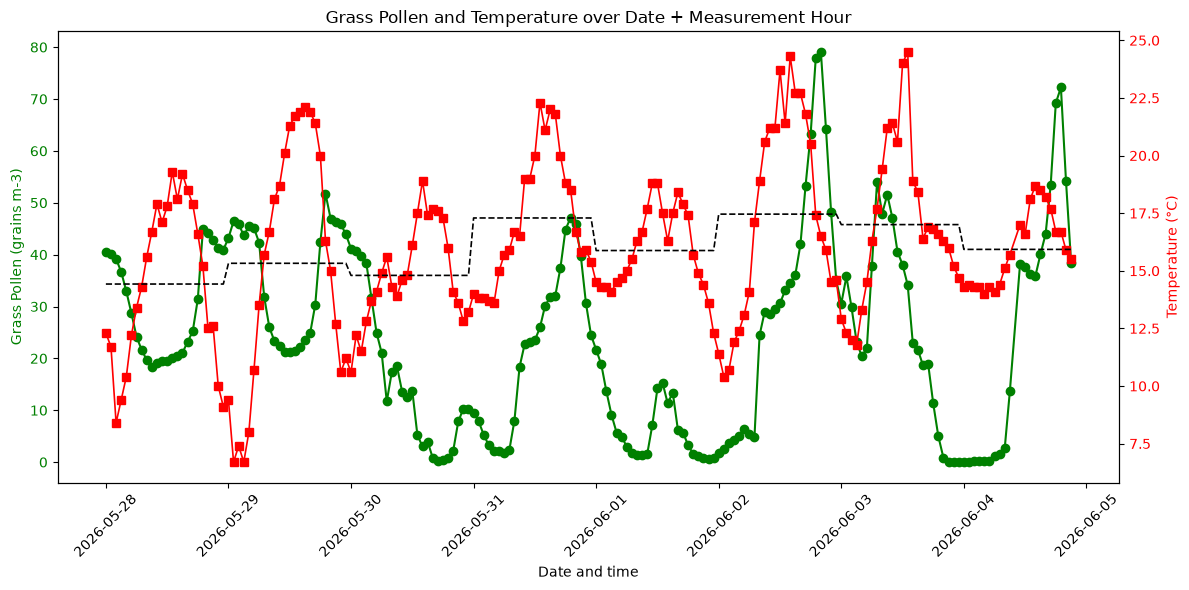

In [29]:
data_1 = plot_df_1['grass_pollen']
data_2 = plot_df_1['temperature']
data_3 = plot_df_1['avg_day_temperature']

x = pd.to_datetime(
    plot_df_1['date'].astype(str)
    + ' '    
    + plot_df_1['measurement_hour'].astype(str)
)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x, data_2, color='red', marker='s', linewidth=1.2)
ax2.plot(x, data_3, color='black', linewidth=1.2, linestyle='--', label='Avg Day Temperature')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date + Measurement Hour')
plt.tight_layout()
plt.show()

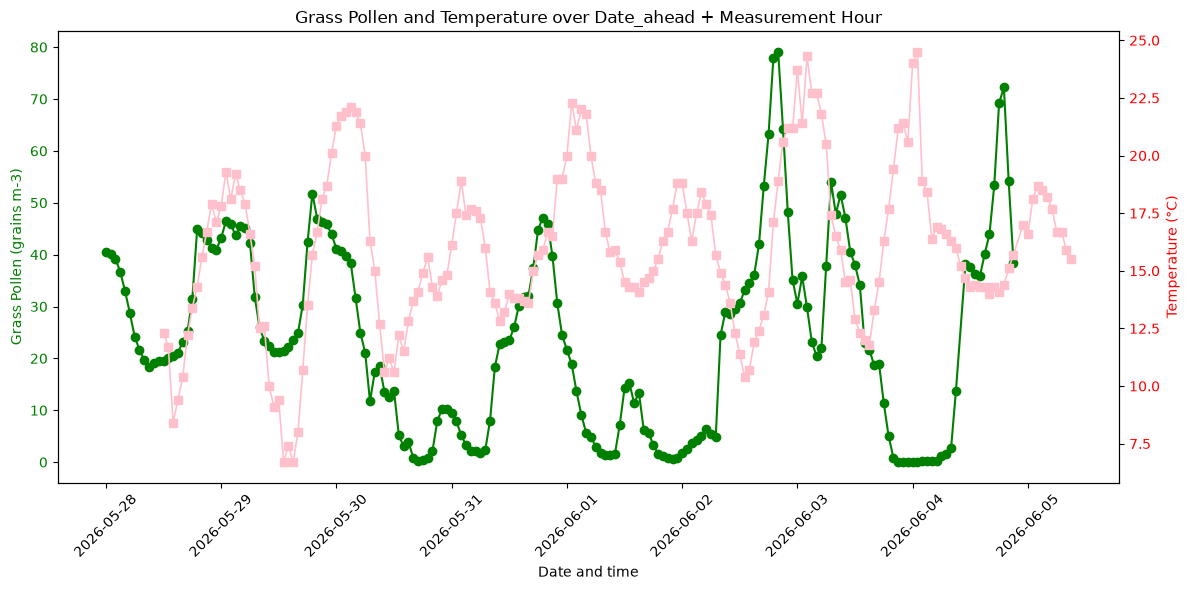

In [30]:
data_1 = plot_df_1['grass_pollen']
data_2 = plot_df_1['temperature']
x = pd.to_datetime(
    plot_df_1['date'].astype(str)
    + ' '    
    + plot_df_1['measurement_hour'].astype(str)
)
x_ahead = plot_df_1['date_N_h_ahead']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x_ahead, data_2, color='pink', marker='s', linewidth=1.2)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date_ahead + Measurement Hour')
plt.tight_layout()
plt.show()

In [31]:
df_merged_from_date_range_2 = df_merged_mean_temperature_by_date[(df_merged_mean_temperature_by_date['date'] >= '2026-07-02') & (df_merged_mean_temperature_by_date['date'] < '2026-07-09')].copy()
plot_df_2 = df_merged_from_date_range_2.sort_values(['date', 'measurement_hour'])
plot_df_2[50:100]

,date,date_N_h_ahead,measurement_hour,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature
426,2026-07-04,2026-07-05 11:00:00,23:00:00,12.200,2.000,220,71.700,0.100,1019.200,2026-07-05,11:00:00,45.742,15.800
397,2026-07-05,2026-07-05 12:00:00,00:00:00,11.400,2.000,250,76.700,0.100,1019.000,2026-07-05,12:00:00,38.463,15.487
398,2026-07-05,2026-07-05 13:00:00,01:00:00,11.200,2.000,250,82.700,0.100,1018.500,2026-07-05,13:00:00,35.792,15.487
399,2026-07-05,2026-07-05 14:00:00,02:00:00,12.800,3.000,230,77.900,0.100,1017.900,2026-07-05,14:00:00,33.288,15.487
400,2026-07-05,2026-07-05 15:00:00,03:00:00,13.200,3.000,230,79.600,0.100,1017.700,2026-07-05,15:00:00,26.512,15.487
401,2026-07-05,2026-07-05 16:00:00,04:00:00,12.600,3.000,220,94.200,0.100,1017.300,2026-07-05,16:00:00,20.931,15.487
402,2026-07-05,2026-07-05 17:00:00,05:00:00,13.200,3.000,210,94.200,0.100,1016.900,2026-07-05,17:00:00,18.963,15.487
403,2026-07-05,2026-07-05 18:00:00,06:00:00,13.200,4.000,230,94.200,0.900,1016.600,2026-07-05,18:00:00,15.270,15.487
404,2026-07-05,2026-07-05 19:00:00,07:00:00,13.600,4.000,220,96.100,0.900,1016.200,2026-07-05,19:00:00,14.845,15.487
405,2026-07-05,2026-07-05 20:00:00,08:00:00,16.400,7.000,240,88.900,0.900,1015.600,2026-07-05,20:00:00,15.682,15.487


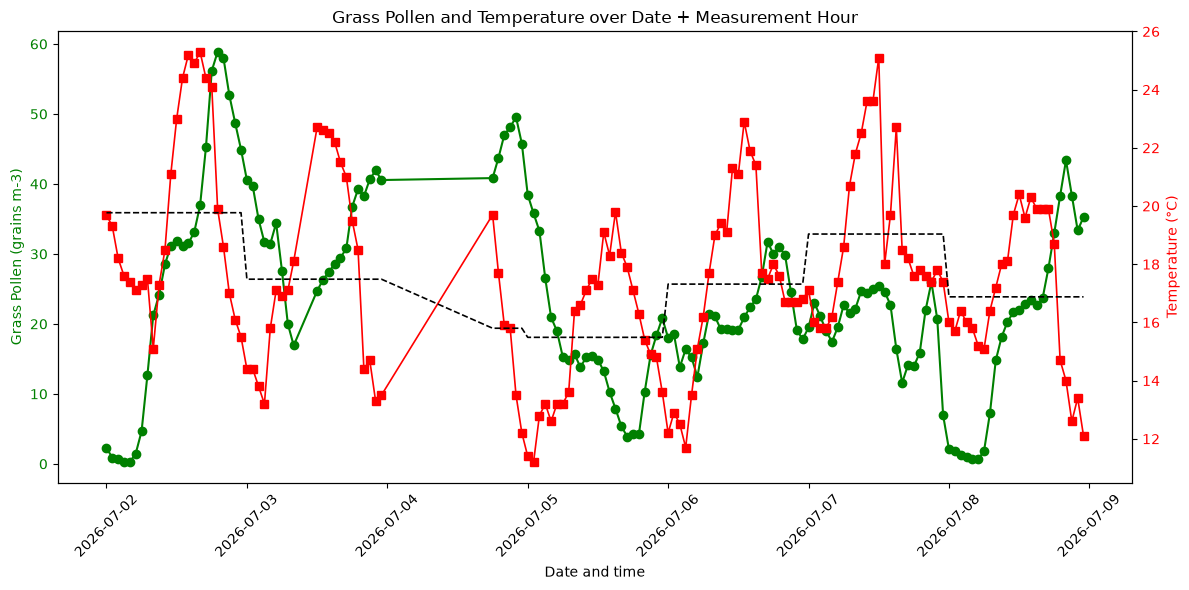

In [32]:
data_1 = plot_df_2['grass_pollen']
data_2 = plot_df_2['temperature']
data_3 = plot_df_2['avg_day_temperature']

x = pd.to_datetime(
    plot_df_2['date'].astype(str)
    + ' '    
    + plot_df_2['measurement_hour'].astype(str)
)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x, data_2, color='red', marker='s', linewidth=1.2)
ax2.plot(x, data_3, color='black', linewidth=1.2, linestyle='--', label='Avg Day Temperature')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date + Measurement Hour')
plt.tight_layout()
plt.show()

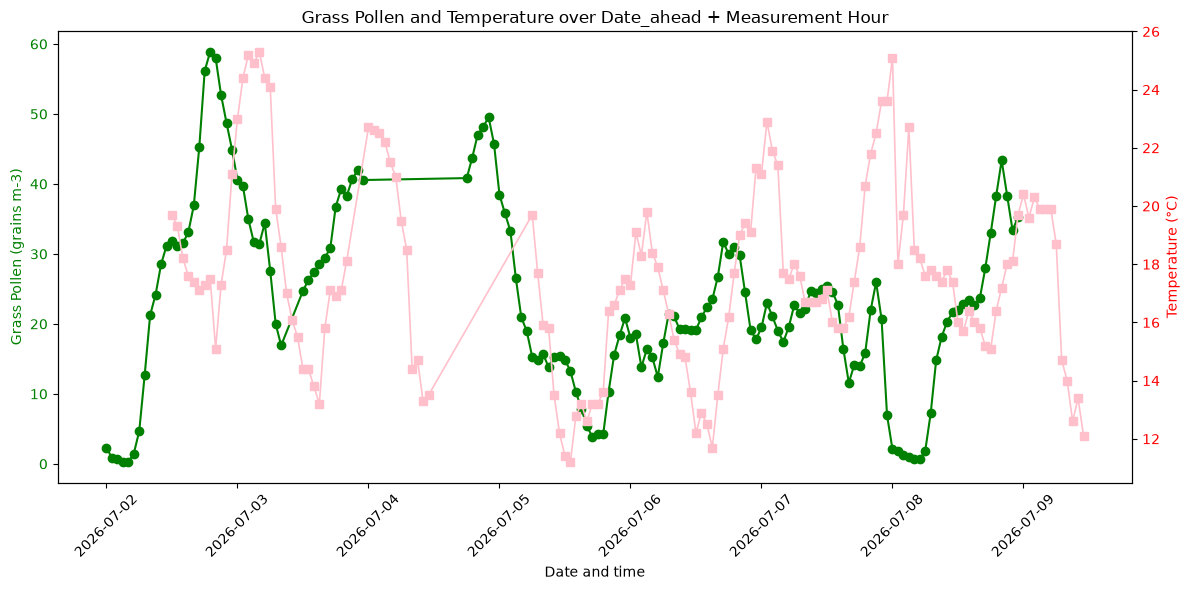

In [33]:
data_1 = plot_df_2['grass_pollen']
data_2 = plot_df_2['temperature']
x = pd.to_datetime(
    plot_df_2['date'].astype(str)
    + ' '    
    + plot_df_2['measurement_hour'].astype(str)
)

x_ahead = plot_df_2['date_N_h_ahead']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x_ahead, data_2, color='pink', marker='s', linewidth=1.2)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date_ahead + Measurement Hour')
plt.tight_layout()
plt.show()

In [34]:
df_merged_from_date_range_3 = df_merged_mean_temperature_by_date[(df_merged_mean_temperature_by_date['date'] >= '2026-06-28') & (df_merged_mean_temperature_by_date['date'] < '2026-07-02')].copy()
plot_df_3 = df_merged_from_date_range_3.sort_values(['date', 'measurement_hour'])
plot_df_3[20:70]


,date,date_N_h_ahead,measurement_hour,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature
564,2026-06-28,2026-06-29 08:00:00,20:00:00,26.400,1.000,290,65.000,0.000,1017.800,2026-06-29,08:00:00,63.685,28.458
565,2026-06-28,2026-06-29 09:00:00,21:00:00,25.800,0.000,0,68.300,0.000,1018.200,2026-06-29,09:00:00,65.491,28.458
566,2026-06-28,2026-06-29 10:00:00,22:00:00,25.300,1.000,40,70.500,0.000,1018.400,2026-06-29,10:00:00,67.530,28.458
567,2026-06-28,2026-06-29 11:00:00,23:00:00,23.700,0.000,0,78.300,0.000,1018.300,2026-06-29,11:00:00,71.064,28.458
520,2026-06-29,2026-06-29 12:00:00,00:00:00,22.700,0.000,0,83.800,0.000,1018.200,2026-06-29,12:00:00,66.219,28.904
521,2026-06-29,2026-06-29 13:00:00,01:00:00,21.400,1.000,20,87.500,0.000,1018.200,2026-06-29,13:00:00,63.154,28.904
522,2026-06-29,2026-06-29 14:00:00,02:00:00,20.800,0.000,0,88.600,0.000,1018.200,2026-06-29,14:00:00,62.713,28.904
523,2026-06-29,2026-06-29 15:00:00,03:00:00,20.600,0.000,0,88.600,0.000,1018.300,2026-06-29,15:00:00,58.815,28.904
524,2026-06-29,2026-06-29 16:00:00,04:00:00,22.200,1.000,270,79.600,0.000,1018.300,2026-06-29,16:00:00,56.225,28.904
525,2026-06-29,2026-06-29 17:00:00,05:00:00,26.800,0.000,0,59.900,0.000,1017.900,2026-06-29,17:00:00,50.333,28.904


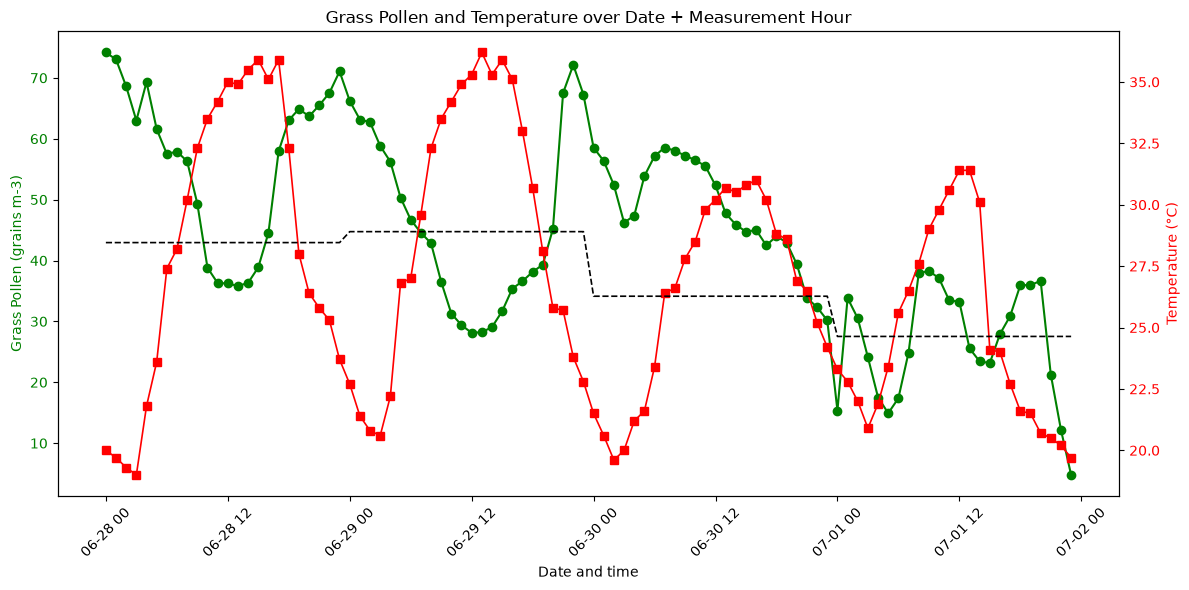

In [35]:
data_1 = plot_df_3['grass_pollen']
data_2 = plot_df_3['temperature']
data_3 = plot_df_3['avg_day_temperature']

x = pd.to_datetime(
    plot_df_3['date'].astype(str)
    + ' '    
    + plot_df_3['measurement_hour'].astype(str)
)

x_ahead = plot_df_3['date_N_h_ahead']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x, data_2, color='red', marker='s', linewidth=1.2)
ax2.plot(x, data_3, color='black', linewidth=1.2, linestyle='--', label='Avg Day Temperature')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date + Measurement Hour')
plt.tight_layout()
plt.show()

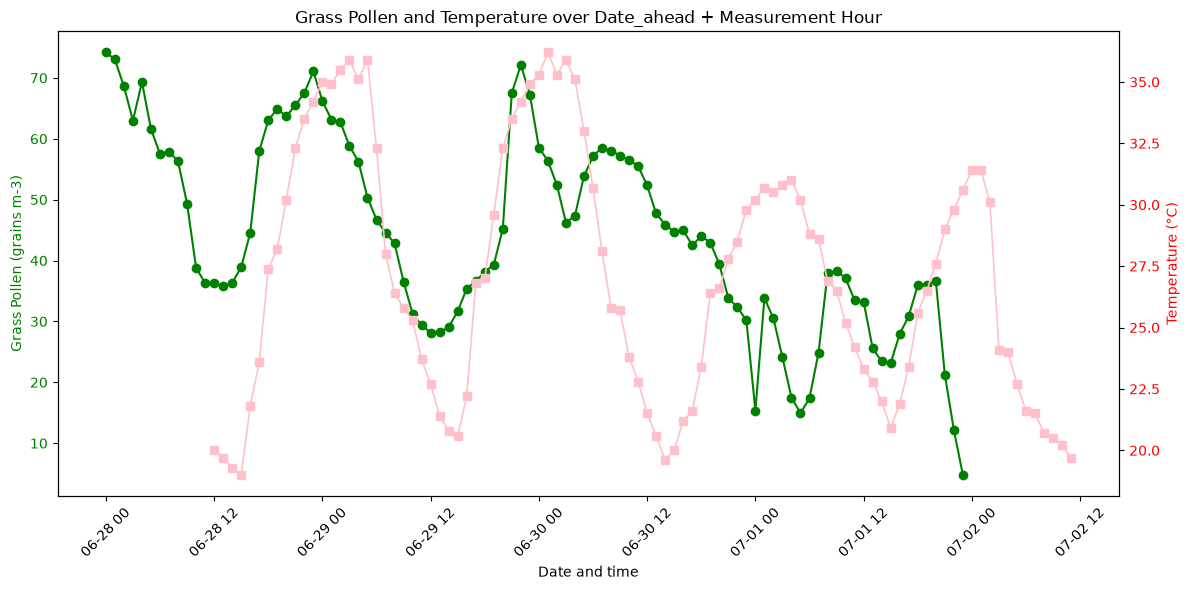

In [36]:
data_1 = plot_df_3['grass_pollen']
data_2 = plot_df_3['temperature']
x = pd.to_datetime(
    plot_df_3['date'].astype(str)
    + ' '    
    + plot_df_3['measurement_hour'].astype(str)
)

x_ahead = plot_df_3['date_N_h_ahead']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x_ahead, data_2, color='pink', marker='s', linewidth=1.2)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date_ahead + Measurement Hour')
plt.tight_layout()
plt.show()